# Task 3: DLRM

## Importing Libraries

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    precision_recall_curve, 
    auc, 
    log_loss, 
    roc_curve
)
from sklearn.calibration import calibration_curve

In [ ]:
# Seed for exact reproducibility across Task 2 and Task 3
np.random.seed(42)
torch.manual_seed(42)

## Loading the Data

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

num_cols = [f'integer_feature_{i}' for i in range(1, 14)]
cat_cols = [f'categorical_feature_{i}' for i in range(1, 27)]

train_df.head()

,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,49.0,520.0,0.0,353.0,5.0,0.0,0.0,0,2,...,1f7fc70b,628f1b8d,9512c20b,c5362157,a9ad4e8e,2b6a4b2f,bc71cd9d,9f4102b0,ff654802,2f33557c
1,0,NaN,408.0,NaN,NaN,NaN,0.0,0.0,-1,1,...,NaN,a1eb1511,0a1d513f,7fdb0729,747f6ecc,62682372,NaN,401a16fe,30436bfc,b757e957
2,0,28.0,37.0,2.0,5.0,4.0,5.0,1.0,974,14,...,753da5f3,d9f758ff,9512c20b,682d90ba,09afda28,307a0f03,f942364c,16e6b497,57e36578,a7ab145d
3,0,1.0,603.0,1.0,NaN,1.0,0.0,0.0,13,1,...,NaN,b8170bba,108a0699,47849e55,73b3f46d,d994ba60,NaN,328e967b,ff654802,2ba8d787
4,0,NaN,525.0,3.0,8.0,126.0,1.0,0.0,10,11,...,753da5f3,b8170bba,55191c09,0e29b5da,0683bc6f,47b99d80,d2b125b2,00a688ec,30436bfc,b757e957


## Preprocessing of Data

In [4]:
# Handle Numerical Missing Values & Log Transform
for col in num_cols:
    median_val = train_df[col].median()
    train_df[col] = np.log1p(np.maximum(0, train_df[col].fillna(median_val)))
    test_df[col] = np.log1p(np.maximum(0, test_df[col].fillna(median_val)))

# Scale Numerical Features without target leakage
scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[num_cols])
X_num_test = scaler.transform(test_df[num_cols])

# Frequency Encoding for High-Cardinality Categorical Features (Top 100)
cat_dims = []
X_cat_train_list, X_cat_test_list = [], []

for col in cat_cols:
    train_df[col] = train_df[col].fillna('missing').astype(str)
    test_df[col] = test_df[col].fillna('missing').astype(str)
    
    top_cats = train_df[col].value_counts().nlargest(100).index
    le = {cat: i + 1 for i, cat in enumerate(top_cats)}  # Index 0 reserved for unseen/rare
    
    X_cat_train_list.append(train_df[col].map(le).fillna(0).astype(int).values)
    X_cat_test_list.append(test_df[col].map(le).fillna(0).astype(int).values)
    cat_dims.append(len(top_cats) + 1)

X_cat_train = np.column_stack(X_cat_train_list)
X_cat_test = np.column_stack(X_cat_test_list)

y_train = train_df['label'].values
y_test = test_df['label'].values

print(y_train)

[0 0 0 ... 0 0 0]


## Creating the Test Train Split
Using the typical 80/20 test-train split for optimal performance.\
Further converting them into tensors

In [ ]:
# Split train set into Train (80%) and Validation (20%) using identical seed
X_num_tr, X_num_val, X_cat_tr, X_cat_val, y_tr, y_val = train_test_split(
    X_num_train, X_cat_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Convert to PyTorch DataLoaders
train_loader = DataLoader(TensorDataset(torch.tensor(X_num_tr, dtype=torch.float32), 
                                         torch.tensor(X_cat_tr, dtype=torch.long), 
                                         torch.tensor(y_tr, dtype=torch.float32)), batch_size=256, shuffle=True)

val_loader = DataLoader(TensorDataset(torch.tensor(X_num_val, dtype=torch.float32), 
                                       torch.tensor(X_cat_val, dtype=torch.long), 
                                       torch.tensor(y_val, dtype=torch.float32)), batch_size=512, shuffle=False)

test_loader = DataLoader(TensorDataset(torch.tensor(X_num_test, dtype=torch.float32), 
                                        torch.tensor(X_cat_test, dtype=torch.long), 
                                        torch.tensor(y_test, dtype=torch.float32)), batch_size=512, shuffle=False)

## DLRM Architecture

In [ ]:
class DLRM(nn.Module):
    def __init__(self, num_features, cat_dims, emb_dim=16, bottom_mlp_dims=[64, 16], top_mlp_dims=[64, 32], no_interaction=False):
        super(DLRM, self).__init__()
        self.no_interaction = no_interaction
        self.emb_dim = emb_dim
        
        # 1. Categorical Embedding Tables
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=dim, embedding_dim=emb_dim) for dim in cat_dims
        ])
        
        # 2. Bottom MLP for Dense Continuous Features
        bottom_layers = []
        in_dim = num_features
        for h_dim in bottom_mlp_dims:
            bottom_layers.append(nn.Linear(in_dim, h_dim))
            bottom_layers.append(nn.ReLU())
            in_dim = h_dim
        self.bottom_mlp = nn.Sequential(*bottom_layers)
        
        # 3. Explicit Interaction Operator
        num_categories = len(cat_dims)
        num_vectors = num_categories + 1  # 26 sparse embeddings + 1 dense representation vector
        
        if self.no_interaction:
            interaction_dim = num_vectors * emb_dim
        else:
            num_pairwise = (num_vectors * (num_vectors - 1)) // 2
            interaction_dim = emb_dim + num_pairwise  # Dense vector + upper triangular dot products
            
        # 4. Top MLP for Final Binary Classification
        top_layers = []
        in_dim = interaction_dim
        for h_dim in top_mlp_dims:
            top_layers.append(nn.Linear(in_dim, h_dim))
            top_layers.append(nn.ReLU())
            in_dim = h_dim
        top_layers.append(nn.Linear(in_dim, 1))
        self.top_mlp = nn.Sequential(*top_layers)

    def interact(self, dense_x, sparse_x):
        # Stack feature representations into matrix shape (batch_size, N, emb_dim)
        T = torch.stack([dense_x] + sparse_x, dim=1)
        
        # Explicit pairwise dot products: B x N x N = T @ T^T
        dot_products = torch.bmm(T, T.transpose(1, 2))
        
        # Vectorize triangular entries without diagonal self-interactions
        N = dot_products.shape[1]
        tril_indices = torch.tril_indices(row=N, col=N, offset=-1)
        interactions = dot_products[:, tril_indices[0], tril_indices[1]]
        
        # Concatenate dense summary vector with explicit pairwise scalar dot products
        return torch.cat([dense_x, interactions], dim=1)

    def forward(self, x_num, x_cat):
        dense_x = self.bottom_mlp(x_num)
        sparse_x = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        
        if self.no_interaction:
            x = torch.cat([dense_x] + sparse_x, dim=1)
        else:
            x = self.interact(dense_x, sparse_x)
            
        return torch.sigmoid(self.top_mlp(x)).squeeze(-1)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Training and Evaluation

In [ ]:
def train_and_eval(model, name, epochs=10, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    start_time = time.time()
    train_losses, val_losses, val_aucs = [], [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x_num, x_cat, y in train_loader:
            optimizer.zero_grad()
            preds = model(x_num, x_cat)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x_num.size(0)
            
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss, val_preds, val_targets = 0.0, [], []
        with torch.no_grad():
            for x_num, x_cat, y in val_loader:
                preds = model(x_num, x_cat)
                val_loss += criterion(preds, y).item() * x_num.size(0)
                val_preds.extend(preds.numpy())
                val_targets.extend(y.numpy())
                
        val_loss /= len(val_loader.dataset)
        val_auc = roc_auc_score(val_targets, val_preds)
        val_losses.append(val_loss)
        val_aucs.append(val_auc)
        print(f"[{name}] Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val ROC-AUC: {val_auc:.4f}")
        
    training_time = time.time() - start_time
    params = count_parameters(model)
    
    # Final Test Set Evaluation
    model.eval()
    test_preds, test_targets = [], []
    with torch.no_grad():
        for x_num, x_cat, y in test_loader:
            test_preds.extend(model(x_num, x_cat).numpy())
            test_targets.extend(y.numpy())
            
    test_preds, test_targets = np.array(test_preds), np.array(test_targets)
    
    test_roc_auc = roc_auc_score(test_targets, test_preds)
    test_log_loss = log_loss(test_targets, test_preds)
    precision, recall, thresholds = precision_recall_curve(test_targets, test_preds)
    test_pr_auc = auc(recall, precision)
    
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1_scores[best_idx]
    
    test_acc = accuracy_score(test_targets, (test_preds >= best_thresh).astype(int))
    
    return {
        'name': name,
        'params': params,
        'training_time': training_time,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_aucs': val_aucs,
        'test_roc_auc': test_roc_auc,
        'test_pr_auc': test_pr_auc,
        'test_log_loss': test_log_loss,
        'best_thresh': best_thresh,
        'best_f1': best_f1,
        'test_acc': test_acc,
        'test_preds': test_preds,
        'test_targets': test_targets
    }

# Execute Model Runs & Ablations
print("--- 1. Training Standard DLRM (Emb Dim = 16) ---")
dlrm_std = DLRM(13, cat_dims, emb_dim=16, bottom_mlp_dims=[64, 16], top_mlp_dims=[64, 32])
res_std = train_and_eval(dlrm_std, "DLRM Standard (Emb 16)")

print("\n--- 2. Training Ablation 1: DLRM Without Interactions ---")
dlrm_no_inter = DLRM(13, cat_dims, emb_dim=16, bottom_mlp_dims=[64, 16], top_mlp_dims=[64, 32], no_interaction=True)
res_no_inter = train_and_eval(dlrm_no_inter, "DLRM No-Interaction")

print("\n--- 3. Training Ablation 2: DLRM Smaller Embedding (Emb Dim = 8) ---")
dlrm_emb8 = DLRM(13, cat_dims, emb_dim=8, bottom_mlp_dims=[64, 8], top_mlp_dims=[64, 32])
res_emb8 = train_and_eval(dlrm_emb8, "DLRM Small Emb (Emb 8)")

## Comaparision and Plots

--- 1. Training Standard DLRM (Emb Dim = 16) ---
[DLRM Standard (Emb 16)] Epoch 01 | Train Loss: 0.1664 | Val Loss: 0.1346 | Val ROC-AUC: 0.6929
[DLRM Standard (Emb 16)] Epoch 02 | Train Loss: 0.1325 | Val Loss: 0.1328 | Val ROC-AUC: 0.7158
[DLRM Standard (Emb 16)] Epoch 03 | Train Loss: 0.1256 | Val Loss: 0.1333 | Val ROC-AUC: 0.7150
[DLRM Standard (Emb 16)] Epoch 04 | Train Loss: 0.1187 | Val Loss: 0.1355 | Val ROC-AUC: 0.7071
[DLRM Standard (Emb 16)] Epoch 05 | Train Loss: 0.1123 | Val Loss: 0.1373 | Val ROC-AUC: 0.7009
[DLRM Standard (Emb 16)] Epoch 06 | Train Loss: 0.1009 | Val Loss: 0.1471 | Val ROC-AUC: 0.6676
[DLRM Standard (Emb 16)] Epoch 07 | Train Loss: 0.0902 | Val Loss: 0.1556 | Val ROC-AUC: 0.6640
[DLRM Standard (Emb 16)] Epoch 08 | Train Loss: 0.0766 | Val Loss: 0.1735 | Val ROC-AUC: 0.6590
[DLRM Standard (Emb 16)] Epoch 09 | Train Loss: 0.0637 | Val Loss: 0.2031 | Val ROC-AUC: 0.6346
[DLRM Standard (Emb 16)] Epoch 10 | Train Loss: 0.0496 | Val Loss: 0.2300 | Val ROC-AUC

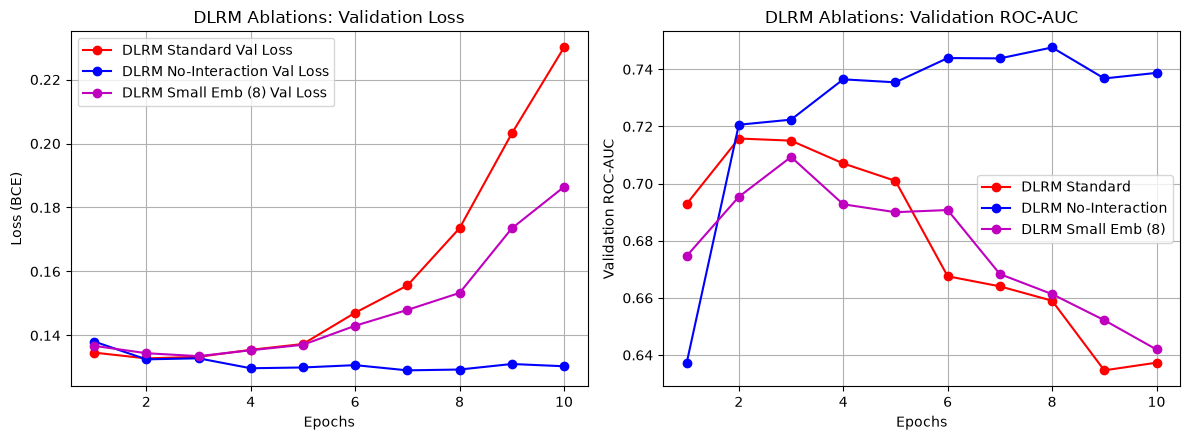

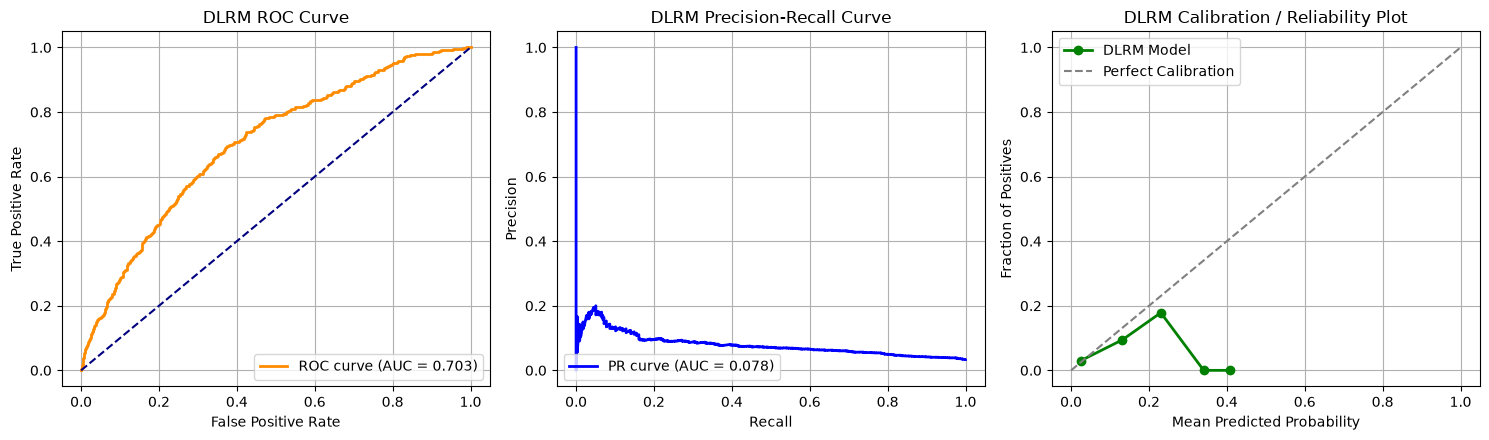

In [1]:
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), res_std['val_losses'], 'r-o', label='DLRM Standard Val Loss')
plt.plot(range(1, 11), res_no_inter['val_losses'], 'b-o', label='DLRM No-Interaction Val Loss')
plt.plot(range(1, 11), res_emb8['val_losses'], 'm-o', label='DLRM Small Emb (8) Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.title('DLRM Ablations: Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), res_std['val_aucs'], 'r-o', label='DLRM Standard')
plt.plot(range(1, 11), res_no_inter['val_aucs'], 'b-o', label='DLRM No-Interaction')
plt.plot(range(1, 11), res_emb8['val_aucs'], 'm-o', label='DLRM Small Emb (8)')
plt.xlabel('Epochs')
plt.ylabel('Validation ROC-AUC')
plt.title('DLRM Ablations: Validation ROC-AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Diagnostic Curves for Best DLRM Variant
fpr, tpr, _ = roc_curve(res_no_inter['test_targets'], res_no_inter['test_preds'])
precision, recall, _ = precision_recall_curve(res_no_inter['test_targets'], res_no_inter['test_preds'])
prob_true, prob_pred = calibration_curve(res_no_inter['test_targets'], res_no_inter['test_preds'], n_bins=10)

plt.figure(figsize=(15, 4.5))
plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {res_no_inter['test_roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DLRM ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f"PR curve (AUC = {res_no_inter['test_pr_auc']:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('DLRM Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color='green', label='DLRM Model')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('DLRM Calibration / Reliability Plot')
plt.legend(loc="upper left")
plt.grid(True)

plt.tight_layout()
plt.show()